In [1]:
from importlib import reload

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from matplotlib import cm
from nonlinear_approximator import (
    activations,
    inference,
    model,
    params,
    training, 
)
%matplotlib inline



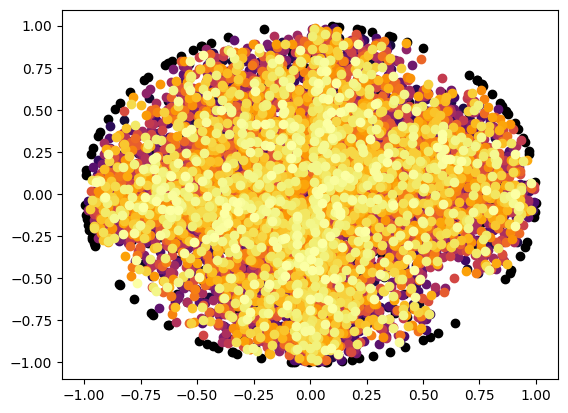

In [6]:
config = params.RegressionParams(
    width=100,
    depth=100,
    input_dimension=2,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

neurons = np.random.normal(loc=0, scale=1, size=(config.input_dimension, config.width))
neurons = neurons / np.linalg.norm(neurons, axis=0)
neurons = np.asarray(neurons)

disp_layers = config.depth # min(8, config.depth + 1)

colors = plt.get_cmap("inferno", disp_layers + 1)
activations_identity = activations.compute_activations(
    neurons, np.asarray(np.eye(2)), config
)

plt.scatter(neurons[0, :], neurons[1, :], color="black")
for idx_layer in range(1, disp_layers):
    plt.scatter(
        activations_identity[idx_layer, :, 0] * neurons[0, :],
        activations_identity[idx_layer, :, 1] * neurons[1, :],
        label=f"Pass {idx_layer + 1}",
        color=colors(idx_layer + 1),
    )

plt.show()

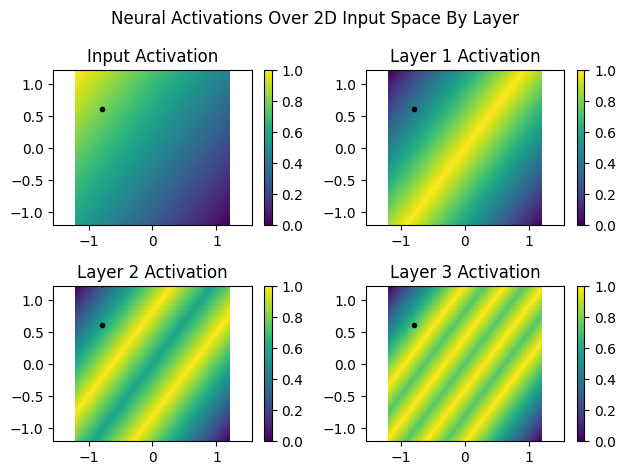

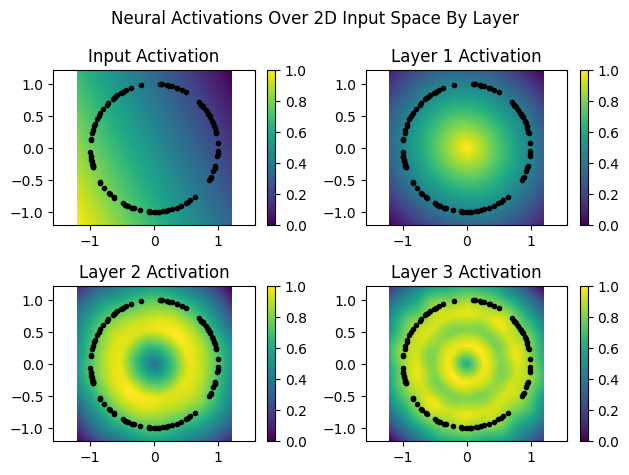

In [ ]:
# evaluate the  activation of a given neuron over a 2d plane. 
# single neuron over 1,3

def acts(neurons, layer, config):
    X, Y = np.meshgrid(xs, xs)
    Z = np.zeros_like(X)
    for idx_neuron in range(neurons.shape[1]):    
        acts_neuron = (1 + X * neurons[0, idx_neuron] + Y *neurons[1, idx_neuron])/2
        for j in range(layer):
            acts_neuron = config.transform_type.value(acts_neuron, config.transform_params)
        if 'Z' not in locals():
            Z = acts_neuron
        else:
            Z += acts_neuron
    return X, Y, Z

xs = np.linspace(-1.2, 1.2, num=100)
layer = 0
plt.figure('input')
plt.clf()

# Neuron count 1
neuron_count = 1
plt.suptitle("Neural Activations Over 2D Input Space By Layer")
plt.subplot(2,2,1)
plt.axis('equal')
X,Y,Z = acts(neurons[:, 0:neuron_count], 0, config)
c = plt.pcolormesh(X,Y, Z)
plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
plt.title("Input Activation")
plt.colorbar()

plt.subplot(2,2,2)
X,Y,Z = acts(neurons[:, 0:neuron_count], 1, config)
c = plt.pcolormesh(X,Y, Z)
plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
plt.title("Layer 1 Activation")
plt.colorbar()
plt.axis('equal')

plt.subplot(2,2,3)
X,Y,Z = acts(neurons[:, 0:neuron_count], 2, config)
c = plt.pcolormesh(X,Y, Z)
plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
plt.title("Layer 2 Activation")
plt.colorbar()
plt.axis('equal')

plt.subplot(2,2,4)
X,Y,Z = acts(neurons[:, 0:neuron_count], 3, config)
c = plt.pcolormesh(X,Y, Z)
plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
plt.title("Layer 3 Activation")
plt.colorbar()
plt.axis('equal')
plt.gcf().tight_layout()

c.set_zorder(0)
plt.show()

# neuron count 100 
neuron_count = 100
plt.figure('input2')
plt.suptitle("Neural Activations Over 2D Input Space By Layer")
plt.subplot(2,2,1)
plt.axis('equal')
X,Y,Z = acts(neurons[:, 0:neuron_count], 0, config)
c = plt.pcolormesh(X,Y, Z)
plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
plt.title("Input Activation")
plt.colorbar()

plt.subplot(2,2,2)
X,Y,Z = acts(neurons[:, 0:neuron_count], 1, config)
c = plt.pcolormesh(X,Y, Z)
plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
plt.title("Layer 1 Activation")
plt.colorbar()
plt.axis('equal')

plt.subplot(2,2,3)
X,Y,Z = acts(neurons[:, 0:neuron_count], 2, config)
c = plt.pcolormesh(X,Y, Z)
plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
plt.title("Layer 2 Activation")
plt.colorbar()
plt.axis('equal')

plt.subplot(2,2,4)
X,Y,Z = acts(neurons[:, 0:neuron_count], 3, config)
c = plt.pcolormesh(X,Y, Z)
plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
plt.title("Layer 3 Activation")
plt.colorbar()
plt.axis('equal')
plt.gcf().tight_layout()


plt.gcf().tight_layout()

c.set_zorder(0)
plt.show()